In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:2px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# [파이썬 기반 데이터 분석 및 시각화]

## data.go.kr 공공데이터 포털에서 배포된 20213년~2015년까지의 와이드포맷 분양가격정보 csv파일과 2015년부터 2024년까지의 롱포맷 분양정보 csv파일을 이용하여 다음의 데이터 정제 및 분석, 시각화한다.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.rc('font', family='Malgun Gothic')

### 1. 2013년부터 2015년 8월까지 분양가 정보를 df_first데이터 프레임 변수에 저장하고, df_first의 내용을 이용하여 heatmap을 그리시오.

In [3]:
# 1) df_first 데이터 프레임 변수 저장
df_first = pd.read_csv(r'C:\ai\Downloads\shareData\분양가격\전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',
                      encoding='cp949')
df_first

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
1,부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,...,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
2,대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,...,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
3,인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,...,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
4,광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,...,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231
5,대전,8321,8321,8321,8341,8341,8341,8333,8333,8333,...,8067,8067,8067,8067,8067,8145,8272,8079,8079,8079
6,울산,8090,8090,8090,8153,8153,8153,8153,8153,8493,...,8891,8891,8526,8526,8629,9380,9192,9190,9190,9215
7,경기,10855,10855,10791,10784,10876,10646,10266,10124,10134,...,10356,10379,10391,10355,10469,10684,10685,10573,10518,10573
8,세종,7601,7600,7532,7814,7908,7934,8067,8067,8141,...,8592,8560,8560,8560,8555,8546,8546,8671,8669,8695
9,강원,6230,6230,6230,6141,6373,6350,6350,6268,6268,...,6365,6365,6348,6350,6182,6924,6846,6986,7019,7008


In [4]:
df_first.set_index('지역', inplace = True)
df_first

,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
지역,,,,,,,,,,,,,,,,,,,,,
서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,9258,...,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,8449,...,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,9973,...,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,7802,...,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231
대전,8321,8321,8321,8341,8341,8341,8333,8333,8333,8048,...,8067,8067,8067,8067,8067,8145,8272,8079,8079,8079
울산,8090,8090,8090,8153,8153,8153,8153,8153,8493,8493,...,8891,8891,8526,8526,8629,9380,9192,9190,9190,9215
경기,10855,10855,10791,10784,10876,10646,10266,10124,10134,10501,...,10356,10379,10391,10355,10469,10684,10685,10573,10518,10573
세종,7601,7600,7532,7814,7908,7934,8067,8067,8141,8282,...,8592,8560,8560,8560,8555,8546,8546,8671,8669,8695


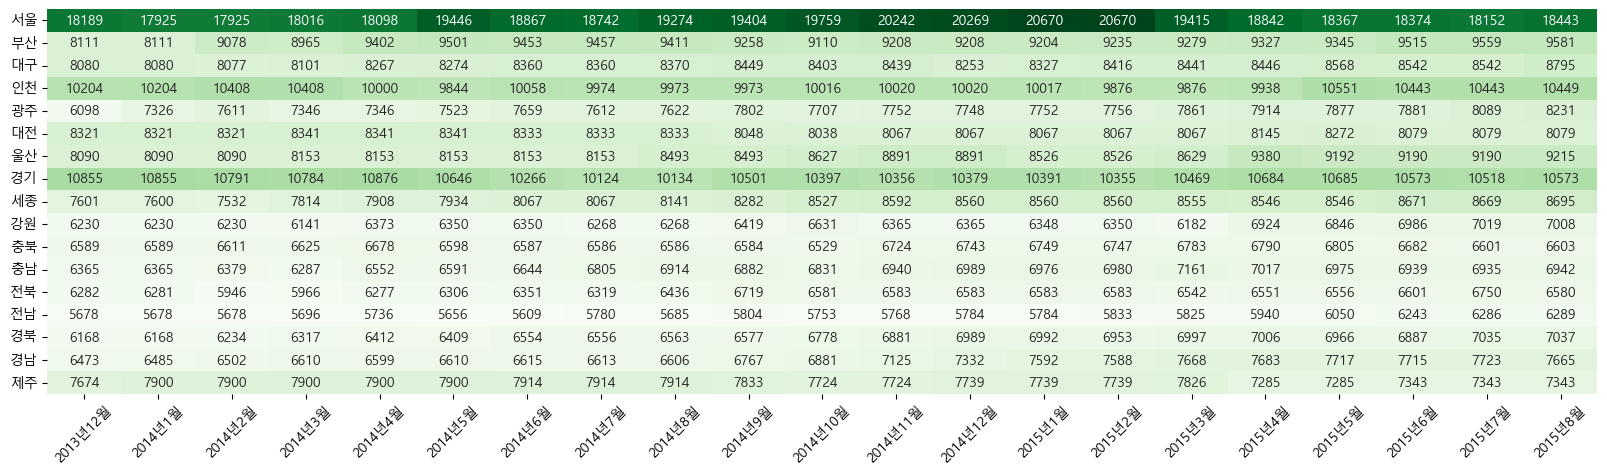

In [5]:
# 2) df_first의 내용을 이용해 heatmap을 그리기
plt.figure(figsize=(20, 5))
sns.heatmap(df_first, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.xticks(rotation=45)
plt.ylabel(None)
plt.show()

### 2. 2015년 10월 이후의 분양가 정보를 df_last 데이터 프레임 변수에 저장 후, 평당분양가격 컬럼을 추가하고 다음을 출력하시오.

In [6]:
# df_last 데이터 프레임 변수에 저장
df_last = pd.read_csv(r'C:/ai/Downloads/shareData/분양가격/주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531.csv',
                      encoding='cp949')
df_last

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
0,서울,모든면적,2015,10,5841
1,서울,전용면적 60제곱미터이하,2015,10,5652
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721
4,서울,전용면적 102제곱미터초과,2015,10,5879
...,...,...,...,...,...
10875,제주,모든면적,2026,5,4473
10876,제주,전용면적 60제곱미터이하,2026,5,NaN
10877,제주,전용면적 60제곱미터초과 85제곱미터이하,2026,5,4485
10878,제주,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN


In [7]:
temp = '5,000'
temp.replace(',','')

'5000'

In [8]:
df_last.loc[0]

지역명                 서울
규모구분              모든면적
연도                2015
월                   10
분양가격(제곱미터당 천원)    5841
Name: 0, dtype: object

In [9]:
def commadrop(row):
    row = row.copy()
    price = row['분양가격(제곱미터당 천원)']
    if pd.isna(price):
        row['평당분양가격'] = np.nan
    elif price.strip()=='' or price=='-' :
        row['평당분양가격'] = np.nan
    elif price.find(',') != -1:
        row['평당분양가격'] = float(price.replace(',', ''))
    else:
        row['평당분양가격'] = float(price)
        
    return row

commadrop(df_last.loc[0])
commadrop(df_last.loc[28])
commadrop(df_last.loc[368])
commadrop(df_last.loc[8863])

지역명                                    대구
규모구분              전용면적 85제곱미터초과 102제곱미터이하
연도                                   2024
월                                       6
분양가격(제곱미터당 천원)                          -
평당분양가격                                NaN
Name: 8863, dtype: object

In [10]:
df_last = df_last.apply(commadrop, axis=1)
df_last

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),평당분양가격
0,서울,모든면적,2015,10,5841,5841.0
1,서울,전용면적 60제곱미터이하,2015,10,5652,5652.0
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882,5882.0
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721,5721.0
4,서울,전용면적 102제곱미터초과,2015,10,5879,5879.0
...,...,...,...,...,...,...
10875,제주,모든면적,2026,5,4473,4473.0
10876,제주,전용면적 60제곱미터이하,2026,5,NaN,NaN
10877,제주,전용면적 60제곱미터초과 85제곱미터이하,2026,5,4485,4485.0
10878,제주,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN,NaN


In [11]:
df_last['규모구분'].unique()

array(['모든면적', '전용면적 60제곱미터이하', '전용면적 60제곱미터초과 85제곱미터이하',
       '전용면적 85제곱미터초과 102제곱미터이하', '전용면적 102제곱미터초과'], dtype=object)

In [12]:
df_last['전용면적'] = df_last['규모구분'].str.replace('전용면적', '').str.replace('이하', '')
df_last['전용면적'] = df_last['전용면적'].str.replace('제곱미터', 'm').str.replace('초과', '~')
df_last['전용면적'] = df_last['전용면적'].str.replace(' ', '')

In [13]:
df_last.drop(['규모구분', '분양가격(제곱미터당 천원)'], axis=1, inplace=True)

In [16]:
col = df_last.pop('전용면적')
print(col)

0            모든면적
1             60m
2         60m~85m
3        85m~102m
4           102m~
           ...   
10875        모든면적
10876         60m
10877     60m~85m
10878    85m~102m
10879       102m~
Name: 전용면적, Length: 10880, dtype: object


In [17]:
df_last.insert(1, '전용면적', col)
df_last

,지역명,전용면적,연도,월,평당분양가격
0,서울,모든면적,2015,10,5841.0
1,서울,60m,2015,10,5652.0
2,서울,60m~85m,2015,10,5882.0
3,서울,85m~102m,2015,10,5721.0
4,서울,102m~,2015,10,5879.0
...,...,...,...,...,...
10875,제주,모든면적,2026,5,4473.0
10876,제주,60m,2026,5,NaN
10877,제주,60m~85m,2026,5,4485.0
10878,제주,85m~102m,2026,5,NaN


### 3. df_last 데이터프레임의 연도별, 지역명별 평당분양가격을 다음과 같이 집계하시오.

### 4. 연도별 평당분양가격의 violinplot에 분포를 추정할 수 있는 그래프를 그리시오.

In [33]:
result = df_last.groupby('연도')['평당분양가격'].mean()
for year, val in result.items():
    print(year, val)

2015 2788.707818930041
2016 2934.25
2017 3143.311794871795
2018 3326.9510337323177
2019 3693.4221491228072
2020 3951.3401360544217
2021 4132.128042328042
2022 4528.031664964249
2023 5118.4608050847455
2024 5816.138011695906
2025 6078.213885778276
2026 6397.401595744681


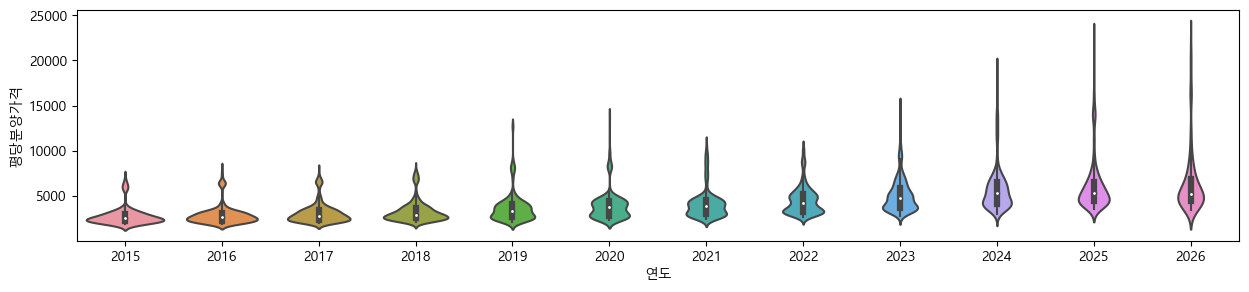

In [43]:
plt.rcParams['figure.figsize'] = (15, 3)
sns.violinplot(data=df_last, x='연도', y='평당분양가격')
plt.show()

### 5. 구조가 다른 와이드포맷 데이터 df_first와 롱포맷 데이터 df_last를 melt와 pivot_table함수를 이용하여, 아래와 같은 하나의 데이터셋으로 합쳐 df변수에 할당하고 df를 출력하시오.